# PA1: Prototipação e Inspeção Exploratória de Dados

Este notebook realiza a inspeção e validação visual dos dados do **Programming Assignment 1**:
1. **Parte 0 (Dataset Sintético):** Visualização das elipses procedurais geradas em canvas $128 \times 128$, verificando elipses encostadas, sobreposições, ruído e contraste.
2. **Parte 1 (Base Real DSB2018):** Amostragem das diferentes modalidades de microscopia (, , ) e fusão de máscaras de instâncias.
3. **Estatísticas Morfológicas:** Análise de densidade de objetos e distribuição de diâmetros de núcleos.
4. **Validação das Métricas:** Demonstração dos algoritmos de matching autoral (*Hungarian* vs. *Greedy*).


In [1]:
import sys
import os
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.dataset import SyntheticDataset, DSB2018Dataset, create_stratified_splits, load_splits
from src.metrics import evaluate_instances, compute_semantic_iou, compute_semantic_dice
from src.utils import colorize_instances, overlay_mask_on_image, plot_sample_comparison, compute_nuclei_size_statistics, plot_dataset_statistics

%matplotlib inline
print("Ambiente configurado com sucesso! PyTorch:", torch.__version__)

Ambiente configurado com sucesso! PyTorch: 2.14.0+cu130


---
## 1. Parte 0: Teste Unitário Sintético (Elipses Procedurais)

O objetivo da **Parte 0** é validar o pipeline antes de tocar nos dados reais:
- Imagens $28 \times 128$ com 5 a 20 elipses de tamanhos e rotações variadas.
- Muitas elipses se tocando/sobrepondo.
- Ruído gaussiano e contraste variáveis.
- Rótulos de instâncias gerados proceduralmente.


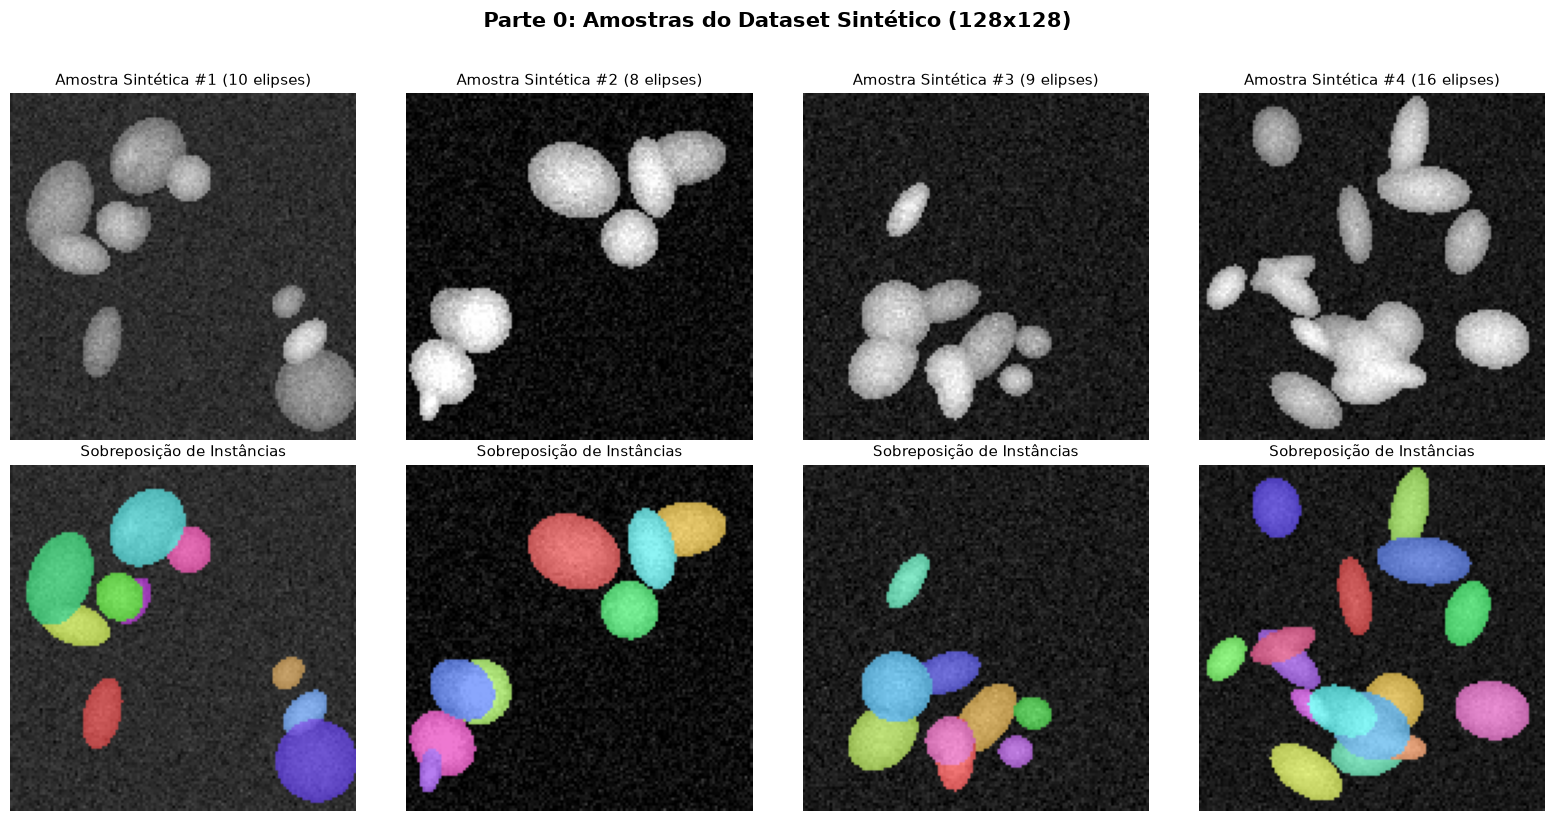

In [3]:
# Criar o gerador sintético determinístico para visualização
synthetic_dataset = SyntheticDataset(num_samples=8, height=128, width=128, min_ellipses=5, max_ellipses=20, seed=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx in range(4):
    sample = synthetic_dataset[idx]
    img = sample["image"].numpy().transpose(1, 2, 0)
    sem = sample["mask_semantic"][0].numpy()
    inst = sample["mask_instance"].numpy()
    
    n_instances = len(np.unique(inst[inst != 0]))
    inst_colored = colorize_instances(inst, seed=idx)
    overlay = overlay_mask_on_image(img, inst_colored, alpha=0.55)
    
    # Linha 1: Imagem Sintética com Ruído
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f"Amostra Sintética #{idx+1} ({n_instances} elipses)", fontsize=11)
    axes[0, idx].axis("off")
    
    # Linha 2: Máscara de Instâncias Colorida (Overlay)
    axes[1, idx].imshow(overlay)
    axes[1, idx].set_title("Sobreposição de Instâncias", fontsize=11)
    axes[1, idx].axis("off")

plt.suptitle("Parte 0: Amostras do Dataset Sintético (128x128)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Parte 1: Base Real DSB2018 (Microscopia Celular)

A base de dados contém cerca de 670 imagens com anotações individuais por núcleo em PNGs separados.
Abaixo inspecionamos amostras reais de diferentes modalidades após a fusão de máscaras pelo .


Total de imagens reais encontradas: 670


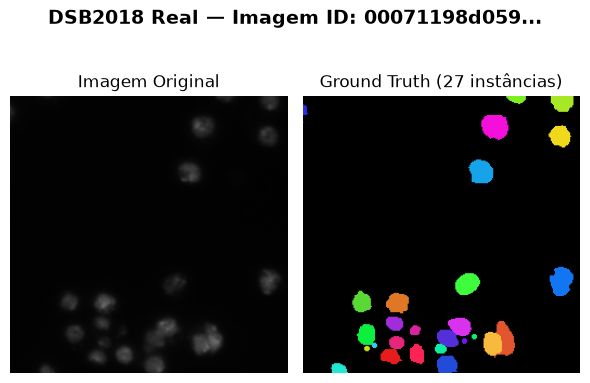

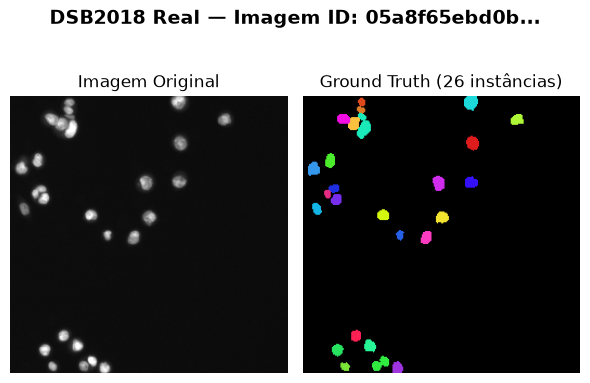

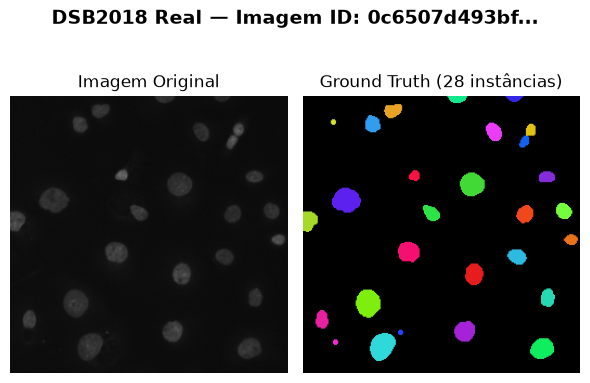

In [9]:
# Carregar dataset real redimensionado para 256x256
dsb_dataset = DSB2018Dataset(root_dir="../data/raw/stage1_train", target_size=(256, 256))
print(f"Total de imagens reais encontradas: {len(dsb_dataset)}")

# Exibir 3 amostras ilustrativas com Ground Truth colorido
sample_indices = [0, 15, 35]
for s_idx in sample_indices:
    sample = dsb_dataset[s_idx]
    img = sample["image"]
    inst = sample["mask_instance"]
    img_id = sample["image_id"]
    
    fig = plot_sample_comparison(
        image=img,
        gt_instance_mask=inst,
        title_prefix=f"DSB2018 Real — Imagem ID: {img_id[:12]}...",
        figsize=(6, 4)
    )
    plt.show()

---
## 3. Estatísticas Morfológicas e Densidade de Núcleos

Compreender a distribuição de tamanhos e contagem de núcleos é fundamental para:
1. **Parte 1 (Item 5):** Analisar como o erro e o mAP variam em função da densidade de objetos.
2. **Parte 5 (Campo Receptivo):** Comparar os diâmetros dos núcleos com o campo receptivo teórico do encoder.


Total de núcleos analisados: 2491
Diâmetro médio: 13.3 px (Min: 1.1 px, Max: 63.2 px)
Contagem média: 49.8 núcleos/imagem (Max: 369)


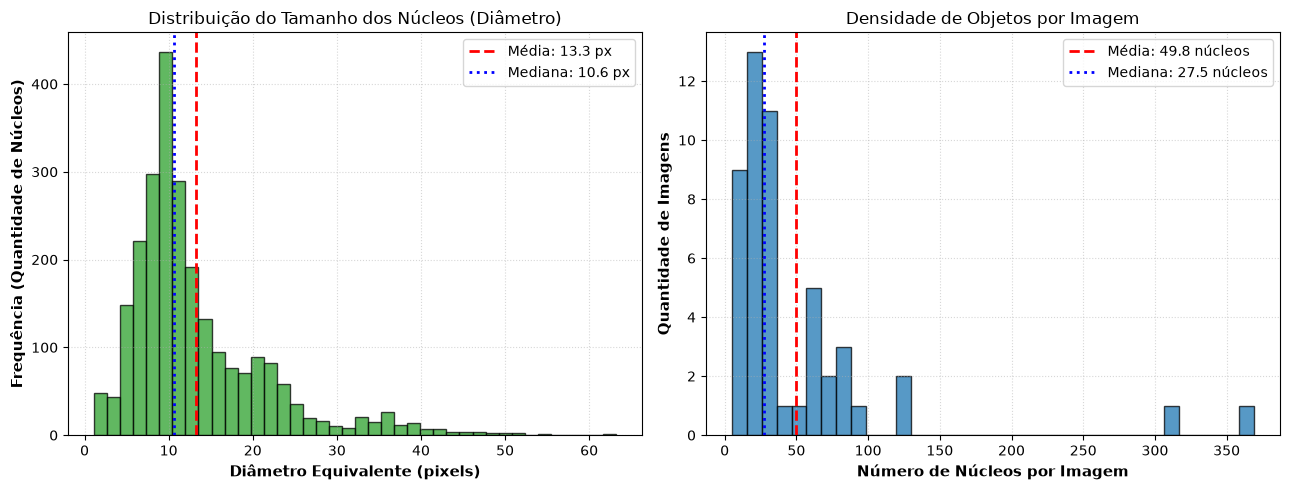

In [10]:
# Coletar máscaras de uma amostragem representativa (50 imagens)
subset_masks = [dsb_dataset[i]["mask_instance"].numpy() for i in range(min(50, len(dsb_dataset)))]
stats = compute_nuclei_size_statistics(subset_masks)

print(f"Total de núcleos analisados: {len(stats['areas'])}")
print(f"Diâmetro médio: {np.mean(stats['diameters']):.1f} px (Min: {np.min(stats['diameters']):.1f} px, Max: {np.max(stats['diameters']):.1f} px)")
print(f"Contagem média: {np.mean(stats['counts_per_image']):.1f} núcleos/imagem (Max: {np.max(stats['counts_per_image'])})")

fig_stats = plot_dataset_statistics(stats)
plt.show()

---
## 4. Validação das Métricas de Matching de Instâncias (Hungarian vs. Greedy)

Demonstração prática dos algoritmos de matching implementados em :
- Criamos uma simulação de núcleos encostados que foram fundidos pela segmentação ingênua (ilustrando o problema que a Parte 1 enfrenta).
- Avaliamos o mAP@[.50:.95] e o erro de contagem resultante.


SIMULAÇÃO DO FRACASSO DA BASELINE (NÚCLEOS ENCOSTADOS)
Objetos Reais (Ground Truth) : 3 núcleos
Objetos Detectados (Ingênuo): 2 instâncias (2 núcleos se fundiram!)
Hungarian mAP@[.50:.95]     : 0.292
Erro Absoluto de Contagem   : 1 núcleo a menos
AP por limiar de IoU (Hungarian): {0.5: 0.6666666666666666, 0.55: 0.25, 0.6: 0.25, 0.65: 0.25, 0.7: 0.25, 0.75: 0.25, 0.8: 0.25, 0.85: 0.25, 0.9: 0.25, 0.95: 0.25}


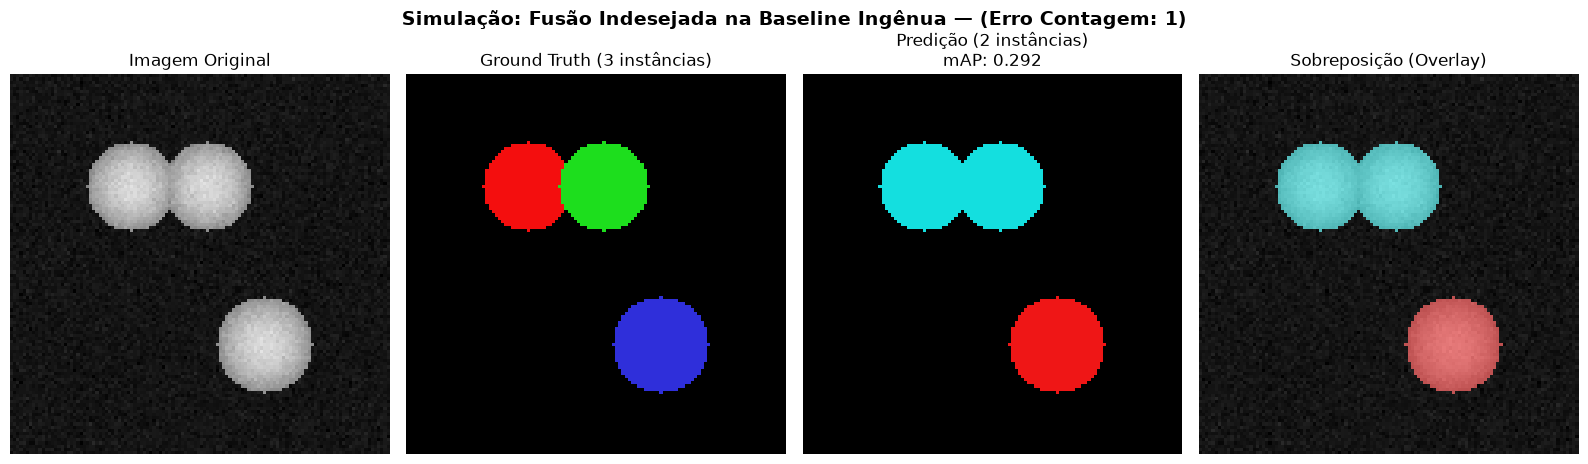

In [12]:
# 1. Criar uma imagem simulada com 3 núcleos realistas
# Núcleos 1 e 2 estão encostados (aglomerados); Núcleo 3 está isolado
h, w = 120, 120
y, x = np.mgrid[0:h, 0:w]

c1 = (35, 38, 14)  # (cy, cx, raio)
c2 = (35, 62, 14)  # Distância entre centros = 24 < 28 (tocando/sobrepondo)
c3 = (85, 80, 15)  # Núcleo isolado

img_sim = np.zeros((h, w), dtype=np.float32) + 0.08  # Fundo escuro
gt_sim = np.zeros((h, w), dtype=np.int64)

for inst_id, (cy, cx, r) in enumerate([c1, c2, c3], start=1):
    dist_sq = ((y - cy)**2 + (x - cx)**2) / (r**2)
    mask = dist_sq <= 1.0
    gt_sim[mask] = inst_id
    blob = 0.85 * (1.0 - 0.35 * dist_sq[mask])
    img_sim[mask] = np.maximum(img_sim[mask], blob)

# Adicionar ruído gaussiano para simular microscopia real
np.random.seed(42)
img_sim = np.clip(img_sim + np.random.normal(0, 0.025, (h, w)), 0.0, 1.0)
img_sim_3ch = np.repeat(img_sim[:, :, None], 3, axis=2)

# 2. Simular a predição da Baseline Ingênua (Limiar + Componentes Conexos)
# Como os núcleos 1 e 2 se tocam, o limiar binário une ambos em um único componente conexo!
from scipy.ndimage import label as ndimage_label
binary_naive = (img_sim >= 0.25).astype(np.uint8)
pred_naive, num_found = ndimage_label(binary_naive)

# 3. Avaliar com as métricas autorais
res_hungarian = evaluate_instances(pred_naive, gt_sim, method="hungarian")
res_greedy = evaluate_instances(pred_naive, gt_sim, method="greedy")

print("=" * 65)
print("SIMULAÇÃO DO FRACASSO DA BASELINE (NÚCLEOS ENCOSTADOS)")
print(f"Objetos Reais (Ground Truth) : 3 núcleos")
print(f"Objetos Detectados (Ingênuo): {num_found} instâncias (2 núcleos se fundiram!)")
print(f"Hungarian mAP@[.50:.95]     : {res_hungarian['mAP']:.3f}")
print(f"Erro Absoluto de Contagem   : {res_hungarian['count_error']} núcleo a menos")
print("=" * 65)
print("AP por limiar de IoU (Hungarian):", res_hungarian["AP_per_iou"])

# 4. Visualização comparativa completa
fig = plot_sample_comparison(
    image=img_sim_3ch,
    gt_instance_mask=gt_sim,
    pred_instance_mask=pred_naive,
    metrics=res_hungarian,
    title_prefix="Simulação: Fusão Indesejada na Baseline Ingênua",
    figsize=(16, 4.5)
)
plt.show()
